# Building Intake database for new extended experiments

In [1]:
import os
from dask.distributed import Client
from access_nri_intake.source.builders import Mom6Builder

In [2]:
client = Client(threads_per_worker = 1)

#### Panan01 rerun for year 2001

In [3]:
%%time
path = "/g/data/ik11/outputs/mom6-panan/panan-01-zstar-2001rerun"
#building
builder = Mom6Builder(
    path=path).build()


CPU times: user 12.4 s, sys: 4.92 s, total: 17.3 s
Wall time: 39.4 s


In [5]:
builder.save(
    name="panan-01-zstar-2001rerun", 
    description="A branched re-run of Panan01 for the year 2001, with aditional heat budget and surface flux diagnostics",
    directory='/g/data/ik11/users/wf4500/Project_panan/GH/Panan_HT_ASC/Jupyter/Intake_catalogs/')

Successfully wrote ESM catalog json file to: file:///g/data/ik11/users/wf4500/Project_panan/GH/Panan_HT_ASC/Jupyter/Intake_catalogs/panan-01-zstar-2001rerun.json


#### Panan005 rerun for year 2001

In [6]:
%%time
path = "/g/data/ik11/outputs/mom6-panan/panan-005-zstar-2001rerun"
#building
builder005 = Mom6Builder(
    path=path).build()


CPU times: user 34.5 s, sys: 14.1 s, total: 48.6 s
Wall time: 1min 46s


In [7]:
builder005.save(
    name="panan-005-zstar-2001rerun", 
    description="A branched re-run of Panan005 for the year 2001, with aditional heat budget and surface flux diagnostics",
    directory='/g/data/ik11/users/wf4500/Project_panan/GH/Panan_HT_ASC/Jupyter/Intake_catalogs/')

Successfully wrote ESM catalog json file to: file:///g/data/ik11/users/wf4500/Project_panan/GH/Panan_HT_ASC/Jupyter/Intake_catalogs/panan-005-zstar-2001rerun.json


## Sanity Check

In [8]:
import intake

In [14]:
catalog01 = intake.open_esm_datastore(
    "/g/data/ik11/users/wf4500/Project_panan/GH/Panan_HT_ASC/Jupyter/Intake_catalogs/panan-01-zstar-2001rerun.json", 
    columns_with_iterables=[
            "variable",
            "variable_long_name",
            "variable_standard_name",
            "variable_cell_methods",
            "variable_units",
    ] # This is important
)

catalog005 = intake.open_esm_datastore(
    "/g/data/ik11/users/wf4500/Project_panan/GH/Panan_HT_ASC/Jupyter/Intake_catalogs/panan-005-zstar-2001rerun.json", 
    columns_with_iterables=[
            "variable",
            "variable_long_name",
            "variable_standard_name",
            "variable_cell_methods",
            "variable_units",
    ] # This is important
)

In [24]:
#defining importing function - below works only for these catalogs with single experiments
def importer(experiment,catalog,variable, frequency = 'fx',start_time=0,end_time=0,chunks=''):
    xarray_open_kwargs = {"chunks": chunks,'decode_timedelta':True}
    if variable == 'volcello' and experiment == 'panan-01-zstar-2001rerun':
        file_id='ocean.1mon.nv:2.xh:3600.xq:3601.yh:845.yq:846.z_i:76.z_l:75'
        var = catalog.search(variable=variable, frequency = frequency,file_id = file_id).to_dask(xarray_open_kwargs=xarray_open_kwargs)
    elif experiment == 'panan-005-zstar-2001rerun' and (variable == 'volcello' or variable == 'T_adx' or variable == 'T_ady' or variable=='thetao'):
        file_id='ocean.1mon.nv:2.xh:7200.xq:7201.yh:1690.yq:1691.z_i:76.z_l:75'
        var = catalog.search(variable=variable, frequency = frequency,file_id = file_id).to_dask(xarray_open_kwargs=xarray_open_kwargs)
    elif experiment == 'panant-0025-zstar-ACCESSyr2' and (variable == 'volcello' or variable == 'T_adx' or variable == 'T_ady' or variable=='thetao'):
        file_id='ocean.1mon.nv:2.xh:14400.xq:14401.yh:3383.yq:3384.z_i:76.z_l:75'
        var = catalog.search(variable=variable, frequency = frequency,file_id = file_id).to_dask(xarray_open_kwargs=xarray_open_kwargs)
    elif frequency == 'fx': 
        var = catalog.search(variable=variable, frequency = frequency).to_dask(xarray_open_kwargs={'decode_timedelta':True})
    else:
        var = catalog.search(variable=variable, frequency = frequency).to_dask(xarray_open_kwargs=xarray_open_kwargs)
    if start_time!=0:
        time_slice='slice(start_time,end_time)'
        return eval("var." + variable + ".sel(time=" + time_slice + ")")
    elif start_time ==0:
        return eval("var." + variable)

# THis definition works only for unique catalogs
def intakelist(catalog):
    return catalog.unique().variable

In [25]:
#testing listing variables
intakelist(catalog01)

['BHEAT',
 'BMELT',
 'E2MELT',
 'average_DT',
 'average_T1',
 'average_T2',
 'net_melt',
 'nv',
 'siconc',
 'sithick',
 'time',
 'time_bnds',
 'xT',
 'xTe',
 'yT',
 'yTe',
 'FA_X',
 'FA_Y',
 'TMELT',
 'fsitherm',
 'xB',
 'yB',
 'mlotst',
 'xh',
 'yh',
 'zos',
 'uo',
 'vo',
 'xq',
 'yq',
 'z_l_sub01',
 'Heat_PmE',
 'LW',
 'SW',
 'T_advection_xy_2d',
 'Th_tendency_vert_remap_2d',
 'boundary_forcing_heat_tendency_2d',
 'evap',
 'frazil',
 'frazil_heat_tendency_2d',
 'frunoff',
 'heat_added',
 'heat_content_fprec',
 'heat_content_frunoff',
 'heat_content_icemelt',
 'heat_content_lprec',
 'heat_content_lrunoff',
 'heat_content_massin',
 'heat_content_massout',
 'hfds',
 'hfrainds',
 'hfrunoffds',
 'latent',
 'latent_evap',
 'latent_fprec_diag',
 'latent_frunoff',
 'lrunoff',
 'net_heat_coupler',
 'net_massin',
 'net_massout',
 'opottempdiff_2d',
 'opottemppmdiff_2d',
 'opottemptend_2d',
 'precip',
 'rsdo',
 'salt_flux',
 'salt_flux_added',
 'salt_flux_in',
 'scalar_axis',
 'seaice_melt',
 '

In [29]:
#testing importing variables
E2MELT01 = importer('panan-01-zstar-2001rerun',catalog01,variable='E2MELT', frequency = '1mon',chunks='auto')
E2MELT005 = importer('panan-005-zstar-2001rerun',catalog005,variable='E2MELT', frequency = '1mon',chunks='auto')
E2MELT005

/g/data/xp65/public/apps/med_conda/envs/analysis3-25.11/lib/python3.11/site-packages/intake_esm/core.py:321: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  records = grouped.get_group(internal_key).to_dict(orient='records')
/g/data/xp65/public/apps/med_conda/envs/analysis3-25.11/lib/python3.11/site-packages/intake_esm/core.py:321: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  records = grouped.get_group(internal_key).to_dict(orient='records')


<xarray.DataArray 'E2MELT' (time: 12, yT: 1690, xT: 7200)> Size: 584MB
dask.array<concatenate, shape=(12, 1690, 7200), dtype=float32, chunksize=(1, 1690, 7200), chunktype=numpy.ndarray>
Coordinates:
  * time     (time) object 96B 2001-01-16 12:00:00 ... 2001-12-16 12:00:00
  * yT       (yT) float64 14kB -81.1 -81.08 -81.06 ... -37.16 -37.12 -37.08
  * xT       (xT) float64 58kB -280.0 -279.9 -279.9 -279.8 ... 79.87 79.92 79.97
Attributes:
    units:          J/m^2
    long_name:      heat needed to melt ice
    cell_methods:   time: mean
    time_avg_info:  average_T1,average_T2,average_DT

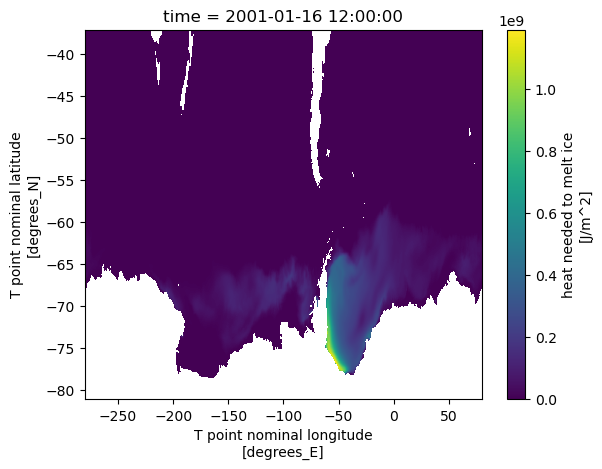

In [32]:
# visual check to see if importing went right
E2MELT01.isel(time=0).plot()